# Lecture 2 - (03/02/2026)

Today's Topics:

- SQL + Python
- Introduction to SQL and Relational Databases
- SQL Visualization

# Bridging SQL and Python

We can start by creating a connection to the database. The code below doesn’t actually connect just yet – we’re just creating the engine with which we will connect to the database.

In [14]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import sqlite3 # pre-installed!

In [15]:
conn = sqlite3.connect("lodes.db") # will make a database in your current directory

We can use our engine to write tables to a database. We do this using the `to_sql` Data Frame method in pandas. Let’s try this out by putting a new state’s data into our lodes.db database.

In [16]:
data_url = 'https://lehd.ces.census.gov/data/lodes/LODES7/md/wac/md_wac_S000_JT00_2015.csv.gz'
df_md = pd.read_csv(data_url,compression='gzip')

In [17]:
df_md.head()

,w_geocode,C000,CA01,CA02,CA03,CE01,CE02,CE03,CNS01,CNS02,...,CFA02,CFA03,CFA04,CFA05,CFS01,CFS02,CFS03,CFS04,CFS05,createdate
0,240010001001023,8,3,4,1,4,4,0,0,0,...,0,0,0,0,0,0,0,0,0,20190826
1,240010001001025,1,0,1,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,20190826
2,240010001001054,10,2,3,5,7,3,0,0,0,...,0,0,0,0,0,0,0,0,0,20190826
3,240010001001113,2,0,2,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,20190826
4,240010001002061,8,4,4,0,7,1,0,0,0,...,0,0,0,0,0,0,0,0,0,20190826


SQL by default lowercases everything, so if we import a database with uppercase column names, we will need to use quotes to access everything, to save ourselves the headache:

In [18]:
df_md.columns = df_md.columns.str.lower()
df_md.columns

Index(['w_geocode', 'c000', 'ca01', 'ca02', 'ca03', 'ce01', 'ce02', 'ce03',
       'cns01', 'cns02', 'cns03', 'cns04', 'cns05', 'cns06', 'cns07', 'cns08',
       'cns09', 'cns10', 'cns11', 'cns12', 'cns13', 'cns14', 'cns15', 'cns16',
       'cns17', 'cns18', 'cns19', 'cns20', 'cr01', 'cr02', 'cr03', 'cr04',
       'cr05', 'cr07', 'ct01', 'ct02', 'cd01', 'cd02', 'cd03', 'cd04', 'cs01',
       'cs02', 'cfa01', 'cfa02', 'cfa03', 'cfa04', 'cfa05', 'cfs01', 'cfs02',
       'cfs03', 'cfs04', 'cfs05', 'createdate'],
      dtype='str')

In [19]:
df_md.to_sql('md_wac_2015', conn, if_exists='replace')

33450

Here, `to_sql()` takes the Data Frame and puts it into the database in the connection `conn`, naming it as the value given in the first argument (in this case, we named it `md_wac_2015`. The last argument, `if_exists='replace'`, makes it so that we replace the table if it exists already.

Some other fun datasets to try yourself!
- [Pokemon](https://raw.githubusercontent.com/veekun/pokedex/master/pokedex/data/csv/pokemon.csv)
- [Marvel](https://raw.githubusercontent.com/fivethirtyeight/data/master/comic-characters/marvel-wikia-data.csv)
- [UFO Sightings](https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2019/2019-06-25/ufo_sightings.csv)
- [Spotify most popular songs](https://raw.githubusercontent.com/anxods/spotify-top-50-songs/refs/heads/main/data/spotify-streaming-top-50-usa.csv)

# Introduction to SQL and Relational Databases

Python is very useful and powerful for doing data analysis. However, it is not meant to be used with extremely large datasets, or to be used as a method of storing data. This is where SQL and relational databases come in. Today we will explore how relational databases work to store data, and how to use SQL to organize and extract the data that we want.

The LODES dataset stands for LEHD Origin-Destination Employment Statistics, produced by the U.S. Census Bureau.

- Tracks employment flows
    - Where people live (residence)
    - Where people work (workplace)
- Covers all jobs covered by unemployment insurance in the USA

We want to explore this, so that we can characterize the data that is available to us. Namely:

- **How many census blocks contain workplaces?**
- **What were the most jobs in a census block?**
- **How many census blocks had over 50 jobs? Over 100?**
- **Among census blocks containing worplaces, what is the average number of jobs per census block?**


## Relational Databases

SQL is a language designed for a very specific purpose: to interact with relational databases.

- **Database**: A database is a structured collection of data. There are various different ways of structuring the database, and there may or may not be information about the relationship between entities in the database.

- **Query**: A query is a request for data from the database.

- **Database Management System (DBMS)**: A DBMS is a system of storing and managing databases, including querying the database.

- **Relational Database Management System (RDBMS)**: In an RDBMS, data records are stored in tables, each of which has a predefined set of columns, the pieces of information captured for each record in a table, and rows in the table, where each row has a place to store a value for every column in the table.

Tables, including their columns, column types and relationships with other tables, are defined in a database schema. Many times, tables will contain a primary key, one or more columns that uniquely define a row. You can think of the primary key as a kind of ID, in which each row is given a unique ID. Tables can also contain foreign keys, which are column(s) that comprise the primary key in another table and, thus, provides a way of matching between multiple tables.

Now, let’s start with some basics. We’ll start by retrieving all columns from the California Workplace Area Characteristic (ca_wac_2015) table. Try running the following query:

In [23]:
pd.read_sql("SELECT * FROM md_wac_2015 LIMIT 10",conn)

,index,w_geocode,c000,ca01,ca02,ca03,ce01,ce02,ce03,cns01,...,cfa02,cfa03,cfa04,cfa05,cfs01,cfs02,cfs03,cfs04,cfs05,createdate
0,0,240010001001023,8,3,4,1,4,4,0,0,...,0,0,0,0,0,0,0,0,0,20190826
1,1,240010001001025,1,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,20190826
2,2,240010001001054,10,2,3,5,7,3,0,0,...,0,0,0,0,0,0,0,0,0,20190826
3,3,240010001001113,2,0,2,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,20190826
4,4,240010001002061,8,4,4,0,7,1,0,0,...,0,0,0,0,0,0,0,0,0,20190826
5,5,240010001002066,2,0,2,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,20190826
6,6,240010001002073,2,1,1,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,20190826
7,7,240010001002097,5,2,3,0,1,3,1,0,...,0,0,0,0,0,0,0,0,0,20190826
8,8,240010001002123,26,5,19,2,13,7,6,0,...,0,0,0,0,0,0,0,0,0,20190826
9,9,240010001002136,23,7,13,3,19,3,1,0,...,0,0,0,0,0,0,0,0,0,20190826


This gave us the entire database! Now let's try to make more specific requests. To do so, we'll need to go over the basics of a SQL command:

- **SELECT**: We start out with the SELECT statement. The SELECT statement specifies which variables (columns) you want.
    - Here, we used `SELECT *`. The `*` just says that we want all the variables.
    - If we wanted a few columns, we would use the column names separated by commas instead of `*` (for example, `w_geocode, createdate`).
- **FROM**: Now, let’s look at the next part of the query, `FROM md_wac_2015`. This part of the query specifies the table, `ca_wac_2015`, from which we want to retrieve the data. Most of your queries will begin in this fashion, describing which columns you want and from which table.
- **LIMIT**: We typically include a `LIMIT` statement at the end of our query so that we don’t get overloaded with rows being output. Here, `LIMIT 10` means that we just want the first ten rows. Many times, the `LIMIT` that you want will be higher than 10 – you might generally prefer to use 1000 or so. Having a `LIMIT` for all queries is highly recommended even if you know only a few rows will be shown, since it acts as a safety precaution against (for example) displaying millions of rows of data.

You may have notived that we chose to use all caps for the commands and lowercase for the data table and schema names. This is just a convention, as SQL is not case sensitive, for example `select * from ca_wac_2015 limit 10` would work just as fine.

Try it yourself!

Go to "https://www.sql-practice.com/" and try to get the first 10 patient ids from the patient database. 

## Checking for duplicates

Let’s say we want to find out how many rows there are. You can do this by using a `COUNT`.

In [24]:
pd.read_sql("SELECT COUNT(*) FROM md_wac_2015",conn)

,COUNT(*)
0,33450


Here, we used COUNT(*), which does a count of all rows, regardless of NULL values. We can instead do a count of all non-NULL values of a certain variable by including that variable instead of *.

In [25]:
pd.read_sql("SELECT COUNT(w_geocode) FROM md_wac_2015",conn)

,COUNT(w_geocode)
0,33450


We can also look at both of these at the same time. This can be helpful for checking for `NULL` values of multiple columns at a time, since we’ll be able to see which ones have less than the total number of rows.

In [26]:
pd.read_sql("SELECT COUNT(*), COUNT(w_geocode), COUNT(C000) FROM md_wac_2015",conn)

,COUNT(*),COUNT(w_geocode),COUNT(C000)
0,33450,33450,33450


While this does verify that there are no `NULL` values, we don't know if there are duplicates. We can verify by using `DISTINCT`

In [28]:
pd.read_sql("SELECT DISTINCT w_geocode FROM md_wac_2015 LIMIT 10",conn)

,w_geocode
0,240010001001023
1,240010001001025
2,240010001001054
3,240010001001113
4,240010001002061
5,240010001002066
6,240010001002073
7,240010001002097
8,240010001002123
9,240010001002136


This shows all the distinct values of `w_geocode`, now we can count to check how many distinct values there are

In [29]:
pd.read_sql("SELECT COUNT(DISTINCT w_geocode) FROM md_wac_2015 LIMIT 10",conn)

,COUNT(DISTINCT w_geocode)
0,33450


Since the count is the same as the number of distinct values, there should be no duplicates in our database.

Also, by chaining together multiple commands we were able to build up a query. When writing a query, start by thinking about the basic parts, and feel free to run any intermediate steps as necessary.

Try it yourself!

Go to "https://www.sql-practice.com/" and try to figure out how many unique allergies there are in the patients dataset.

## Using Conditional Statements

Suppose we want to look at a subset of the data. We can use the `WHERE` statement to create conditional statements to do this.

In [30]:
pd.read_sql("SELECT * FROM md_wac_2015 WHERE c000 < 100 LIMIT 10",conn)

,index,w_geocode,c000,ca01,ca02,ca03,ce01,ce02,ce03,cns01,...,cfa02,cfa03,cfa04,cfa05,cfs01,cfs02,cfs03,cfs04,cfs05,createdate
0,0,240010001001023,8,3,4,1,4,4,0,0,...,0,0,0,0,0,0,0,0,0,20190826
1,1,240010001001025,1,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,20190826
2,2,240010001001054,10,2,3,5,7,3,0,0,...,0,0,0,0,0,0,0,0,0,20190826
3,3,240010001001113,2,0,2,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,20190826
4,4,240010001002061,8,4,4,0,7,1,0,0,...,0,0,0,0,0,0,0,0,0,20190826
5,5,240010001002066,2,0,2,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,20190826
6,6,240010001002073,2,1,1,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,20190826
7,7,240010001002097,5,2,3,0,1,3,1,0,...,0,0,0,0,0,0,0,0,0,20190826
8,8,240010001002123,26,5,19,2,13,7,6,0,...,0,0,0,0,0,0,0,0,0,20190826
9,9,240010001002136,23,7,13,3,19,3,1,0,...,0,0,0,0,0,0,0,0,0,20190826


We can also use more complicated conditional statements.

In [32]:
pd.read_sql("SELECT * FROM md_wac_2015 WHERE (c000 < 10) AND (ca01 = 1) LIMIT 10",conn)

,index,w_geocode,c000,ca01,ca02,ca03,ce01,ce02,ce03,cns01,...,cfa02,cfa03,cfa04,cfa05,cfs01,cfs02,cfs03,cfs04,cfs05,createdate
0,6,240010001002073,2,1,1,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,20190826
1,20,240010001003090,8,1,7,0,1,6,1,0,...,0,0,0,0,0,0,0,0,0,20190826
2,21,240010001003107,4,1,0,3,1,0,3,0,...,0,0,0,0,0,0,0,0,0,20190826
3,25,240010002001003,6,1,5,0,0,5,1,0,...,0,0,0,0,0,0,0,0,0,20190826
4,26,240010002001008,1,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,20190826
5,38,240010002003006,7,1,4,2,1,6,0,0,...,0,0,0,0,0,0,0,0,0,20190826
6,43,240010002003046,9,1,6,2,0,4,5,0,...,0,0,0,0,0,0,0,0,0,20190826
7,50,240010003001000,2,1,1,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,20190826
8,60,240010004001008,3,1,1,1,2,1,0,0,...,0,0,0,0,0,0,0,0,0,20190826
9,74,240010004002049,5,1,1,3,3,2,0,0,...,0,0,0,0,0,0,0,0,0,20190826


In [33]:
pd.read_sql("SELECT COUNT(*) FROM md_wac_2015 WHERE (c000 < 10) AND (ca01 = 1) LIMIT 10",conn)

,COUNT(*)
0,2910


This query finds all the values where `c000` is less than 10 and `ca01` is equal to 1 and takes a count of it.

Using `OR` behaves the same way

In [35]:
pd.read_sql("SELECT * FROM md_wac_2015 WHERE (c000 = 2) OR (ca01 = 1) LIMIT 10",conn)

,index,w_geocode,c000,ca01,ca02,ca03,ce01,ce02,ce03,cns01,...,cfa02,cfa03,cfa04,cfa05,cfs01,cfs02,cfs03,cfs04,cfs05,createdate
0,3,240010001001113,2,0,2,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,20190826
1,5,240010001002066,2,0,2,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,20190826
2,6,240010001002073,2,1,1,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,20190826
3,11,240010001002147,14,1,10,3,4,4,6,0,...,0,0,0,0,0,0,0,0,0,20190826
4,17,240010001002233,15,1,6,8,14,1,0,0,...,0,0,0,0,0,0,0,0,0,20190826
5,20,240010001003090,8,1,7,0,1,6,1,0,...,0,0,0,0,0,0,0,0,0,20190826
6,21,240010001003107,4,1,0,3,1,0,3,0,...,0,0,0,0,0,0,0,0,0,20190826
7,23,240010001003156,2,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,20190826
8,24,240010001003199,2,0,1,1,0,2,0,0,...,0,0,0,0,0,0,0,0,0,20190826
9,25,240010002001003,6,1,5,0,0,5,1,0,...,0,0,0,0,0,0,0,0,0,20190826


### Common Comparison Operators

Though there are some more complicated comparison operators (if you're curious, feel free to look up what `LIKE` and `IN` do), these should cover most of what you want to do.

- **`=`**: equal to
- **`!=`** or "**`<>`**": not equal to
- **`<`**: less than
- **`<=`**: less-than-or-equal-to
- **`>`**: greater than
- **`>=`**: greater-than-or-equal-to
- **`IS NULL`** and **`IS NOT NULL`**: The signifier of a row in a column not having a value is a special keyword: `NULL`.  To check for `NULL`, you use `IS NULL` or `IS NOT NULL`, rather than "=" or "!=". For example, to count the number of rows with `NULL` values for `c000` we might use the following:

Try it yourself!

Go to "https://www.sql-practice.com/" and try to figure out how many people are allergic to "Penicillin" or "Honey"

## SQL Visualization

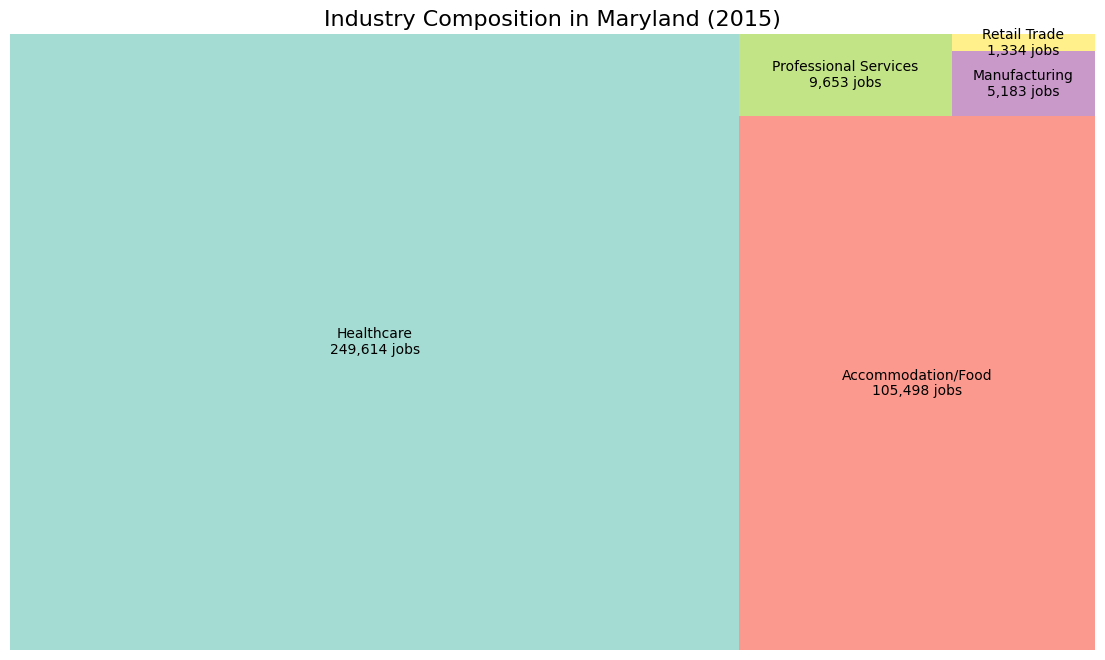

In [49]:
import squarify  
query = """
SELECT 
    'Manufacturing' as industry,
    SUM(cns01) as jobs
FROM md_wac_2015 
UNION ALL
SELECT 
    'Retail Trade',
    SUM(cns02)
FROM md_wac_2015 
UNION ALL
SELECT 
    'Professional Services',
    SUM(cns03)
FROM md_wac_2015 
UNION ALL
SELECT 
    'Healthcare',
    SUM(cns12)
FROM md_wac_2015 
UNION ALL
SELECT 
    'Accommodation/Food',
    SUM(cns05)
FROM md_wac_2015 
ORDER BY jobs DESC
"""

industry_totals = pd.read_sql(query, conn)

# Create treemap
plt.figure(figsize=(14, 8))
colors = plt.cm.Set3(np.linspace(0, 1, len(industry_totals)))
squarify.plot(sizes=industry_totals['jobs'],
             label=[f"{row['industry']}\n{row['jobs']:,} jobs" 
                    for _, row in industry_totals.iterrows()],
             color=colors, alpha=0.8)
plt.title('Industry Composition in Maryland (2015)', fontsize=16)
plt.axis('off')
plt.show()

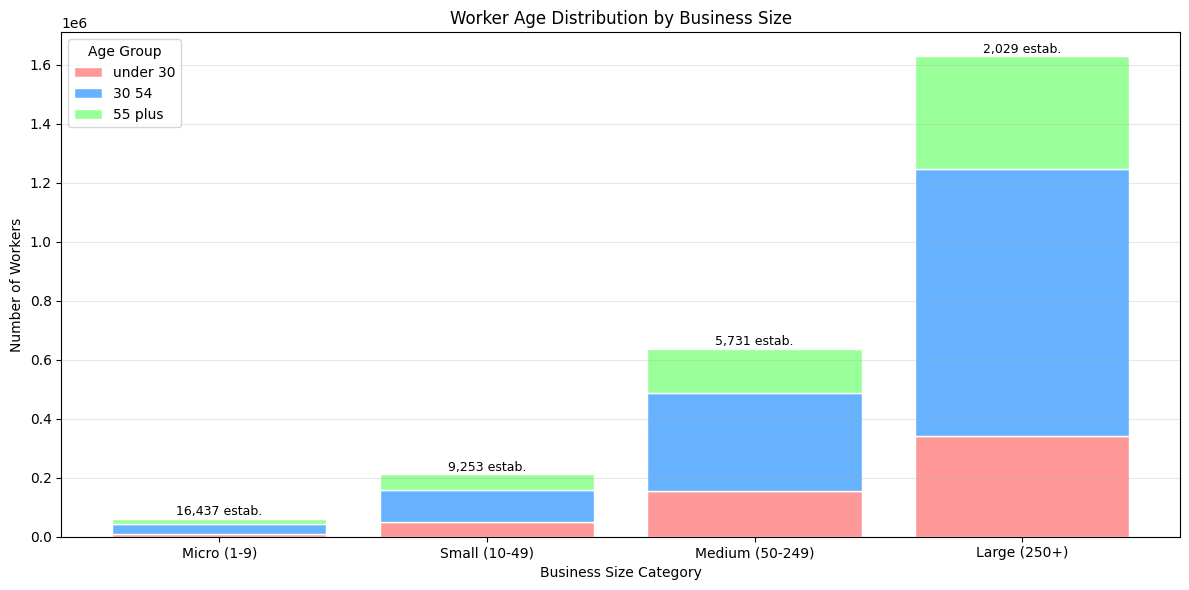

In [52]:
query = """
SELECT 
    CASE 
        WHEN c000 < 10 THEN 'Micro (1-9)'
        WHEN c000 BETWEEN 10 AND 49 THEN 'Small (10-49)'
        WHEN c000 BETWEEN 50 AND 249 THEN 'Medium (50-249)'
        ELSE 'Large (250+)'
    END as business_size,
    SUM(ca01) as workers_under_30,
    SUM(ca02) as workers_30_54,
    SUM(ca03) as workers_55_plus,
    COUNT(*) as num_establishments
FROM md_wac_2015 
WHERE c000 > 0
GROUP BY business_size
ORDER BY 
    CASE business_size
        WHEN 'Micro (1-9)' THEN 1
        WHEN 'Small (10-49)' THEN 2
        WHEN 'Medium (50-249)' THEN 3
        ELSE 4
    END
"""

age_data = pd.read_sql(query, conn)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(age_data))
bottom = np.zeros(len(age_data))

age_groups = ['workers_under_30', 'workers_30_54', 'workers_55_plus']
colors = ['#FF9999', '#66B2FF', '#99FF99']

for i, (col, color) in enumerate(zip(age_groups, colors)):
    ax.bar(x, age_data[col], bottom=bottom, 
           label=col.replace('workers_', '').replace('_', ' '),
           color=color, edgecolor='white')
    bottom += age_data[col]

ax.set_xlabel('Business Size Category')
ax.set_ylabel('Number of Workers')
ax.set_title('Worker Age Distribution by Business Size')
ax.set_xticks(x)
ax.set_xticklabels(age_data['business_size'])
ax.legend(title='Age Group')
ax.grid(axis='y', alpha=0.3)

for i, (size, count) in enumerate(zip(age_data['business_size'], age_data['num_establishments'])):
    ax.text(i, bottom[i] + 1000, f'{count:,} estab.', 
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()